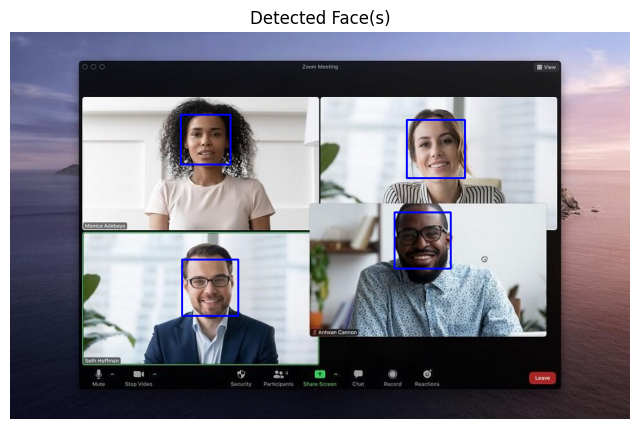

In [1]:
# Code Example 1: Face Detection Using Haar Cascade
import cv2 
import matplotlib.pyplot as plt
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
img = cv2.imread("D:/23108106/A22.jpg") 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
for (x, y, w, h) in faces: 
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
plt.figure(figsize=(8, 6)) 
plt.imshow(img_rgb) 
plt.title("Detected Face(s)") 
plt.axis('off') 
plt.show()

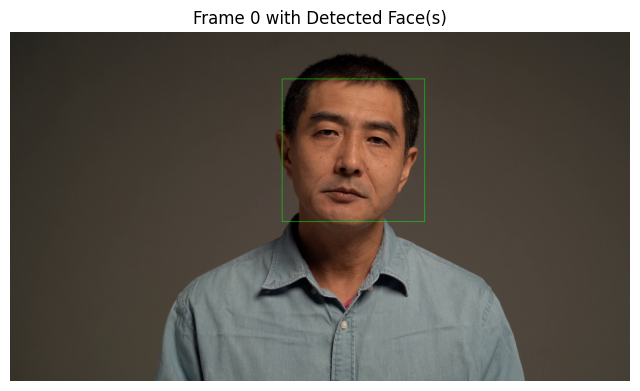

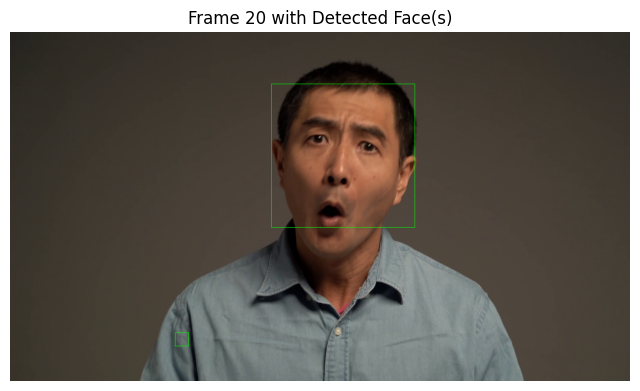

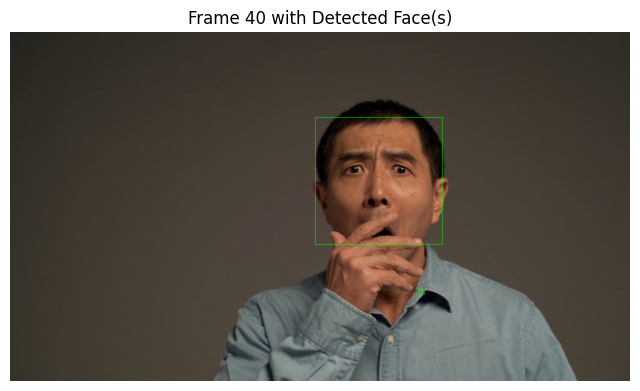

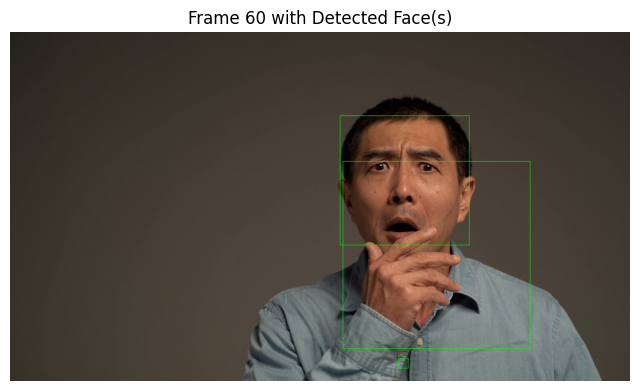

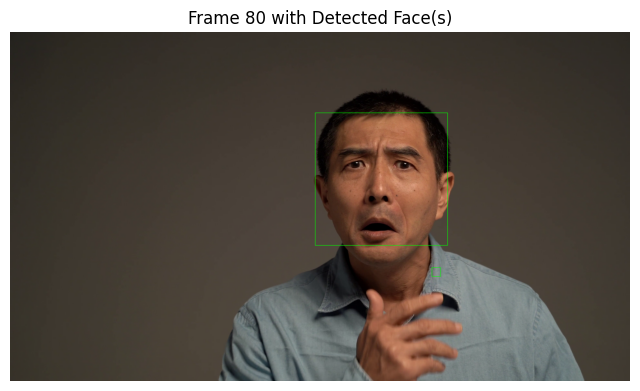

In [2]:
# Code Example 2: Real-Time Face Detection with Webcam
import cv2 
import matplotlib.pyplot as plt
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
cap = cv2.VideoCapture("D:/23108106/122389-725067792.mp4")
frame_count = 0 
while True: 
    ret, frame = cap.read() 
    if not ret or frame_count >= 100:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) 
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in faces: 
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    if frame_count % 20 == 0: 
        plt.figure(figsize=(8, 5)) 
        plt.imshow(rgb) 
        plt.title(f"Frame {frame_count} with Detected Face(s)") 
        plt.axis('off') 
        plt.show()
    frame_count += 1
cap.release()

Access Denied (Confidence: 84)


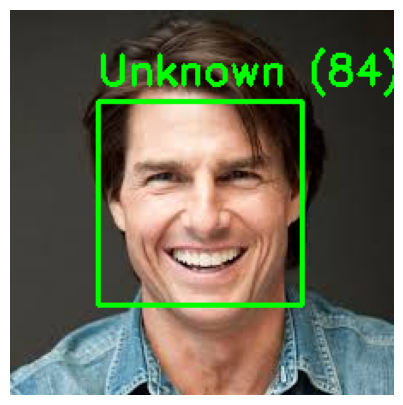

In [3]:
# Case Study 1: Automated Celebrity Face Recognition for Media Archiving
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
def load_dataset(dataset_path):
    images = []
    labels = []
    label_dict = {}
    current_label = 0
    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)
        if os.path.isdir(person_path):
            label_dict[current_label] = person_name
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None and img.shape[0] > 0 and img.shape[1] > 0:
                    images.append(img)
                    labels.append(current_label)
                else:
                    print(f"Failed to load or invalid image: {img_path}")
            current_label += 1
    return images, labels, label_dict
dataset_path = "D:/23108106/Dataset/Faces"
images, labels, label_dict = load_dataset(dataset_path)
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))
recognizer.save('D:/23108106/face_recognizer.yml')
with open("label_map.txt", "w") as f:
    for label, name in label_dict.items():
        f.write(f"{label}:{name}\n")
recognizer.read('D:/23108106/face_recognizer.yml')
label_map = {}
with open("label_map.txt", "r") as f:
    for line in f:
        label, name = line.strip().split(":")
        label_map[int(label)] = name
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
test_img_path = "D:/23108106/A23.jpg"
img = cv2.imread(test_img_path)
if img is None:
    raise ValueError("Test image not loaded! Check the path.")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,    
    minNeighbors=3,       
    minSize=(30, 30)       
)
confidence_threshold = 80  
if len(faces) == 0:
    print("No faces detected!")
else:
    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        label, confidence = recognizer.predict(roi_gray)
        name = label_map.get(label, "Unknown")
        display_name = name if confidence < confidence_threshold else "Unknown"
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img, f"{display_name} ({int(confidence)})",
                    (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        if display_name != "Unknown":
            print(f"Unlocked: {display_name} (Confidence: {int(confidence)})")
        else:
            print(f"Access Denied (Confidence: {int(confidence)})")
plt.figure(figsize=(8,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Access Denied (Confidence: 84)


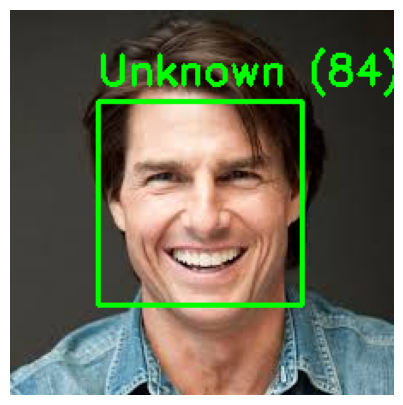

In [4]:
# Case Study 2: Face Unlock in Smartphones
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
def load_dataset(dataset_path):
    images = []
    labels = []
    label_dict = {}
    current_label = 0
    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)
        if os.path.isdir(person_path):
            label_dict[current_label] = person_name
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None and img.shape[0] > 0 and img.shape[1] > 0:
                    images.append(img)
                    labels.append(current_label)
                else:
                    print(f"Failed to load or invalid image: {img_path}")
            current_label += 1
    return images, labels, label_dict
dataset_path = "D:/23108106/Dataset/Faces"
images, labels, label_dict = load_dataset(dataset_path)
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))
recognizer.save('face_recognizer.yml')
with open("label_map.txt", "w") as f:
    for label, name in label_dict.items():
        f.write(f"{label}:{name}\n")
recognizer.read("face_recognizer.yml")
label_map = {}
with open("label_map.txt", "r") as f:
    for line in f:
        label, name = line.strip().split(":")
        label_map[int(label)] = name
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
test_img_path = "D:/23108106/A23.jpg"
img = cv2.imread(test_img_path)
if img is None:
    raise ValueError("Test image not loaded! Check the path.")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=3, minSize=(30, 30))
confidence_threshold = 80  
if len(faces) == 0:
    print("No faces detected!")
else:
    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        label, confidence = recognizer.predict(roi_gray)
        name = label_map.get(label, "Unknown")
        if confidence < confidence_threshold:
            display_name = name
            print(f"Unlocked: {name} (Confidence: {int(confidence)})")
        else:
            display_name = "Unknown"
            print(f"Access Denied (Confidence: {int(confidence)})")
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img, f"{display_name} ({int(confidence)})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

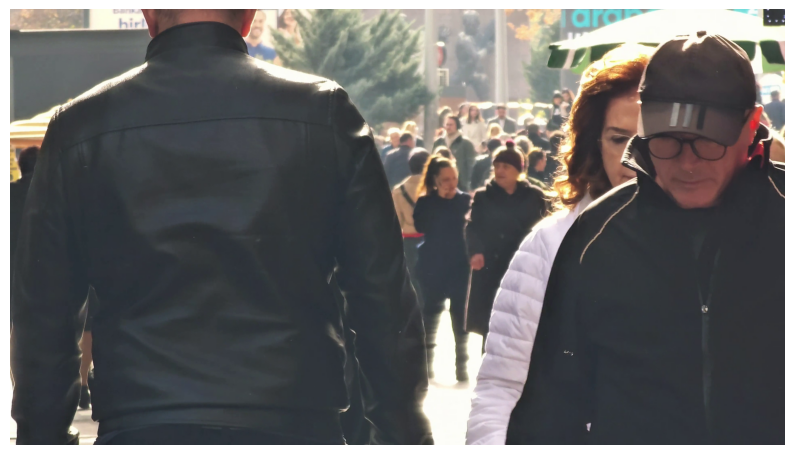

Attendance saved -> attendance_log.csv


In [5]:
# Case Study 1: Smart Attendance System for Universities
import cv2
import numpy as np
import os
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
from IPython.display import clear_output
def load_dataset(dataset_path):
    images, labels, label_map = [], [], {}
    current_label = 0
    for person in os.listdir(dataset_path):
        person_folder = os.path.join(dataset_path, person)
        if os.path.isdir(person_folder):
            label_map[current_label] = person
            for img_name in os.listdir(person_folder):
                img_path = os.path.join(person_folder, img_name)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                images.append(gray)
                labels.append(current_label)
            current_label += 1
    return images, labels, label_map
dataset_path = "D:/23108106/Dataset/Faces"
images, labels, label_map = load_dataset(dataset_path)
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))
attendance = {}
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
cap = cv2.VideoCapture("D:/23108106/Lecture A.mp4")
frame_skip = 5
frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1
    if frame_count % frame_skip != 0:
        continue
    h, w = frame.shape[:2]
    scale = 640 / w
    small_frame = cv2.resize(frame, (640, int(h * scale)))
    gray = cv2.cvtColor(small_frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=4)
    for (x, y, w_f, h_f) in faces:
        roi_gray = gray[y:y+h_f, x:x+w_f]
        label, conf = recognizer.predict(roi_gray)
        name = label_map.get(label, "Unknown")
        if conf < 80:
            if name not in attendance:
                attendance[name] = datetime.now().strftime("%H:%M:%S")
        x1, y1 = int(x / scale), int(y / scale)
        x2, y2 = int((x + w_f) / scale), int((y + h_f) / scale)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f"{name}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    clear_output(wait=True)
    plt.show()
cap.release()
df = pd.DataFrame(list(attendance.items()), columns=["Name", "Time"])
df.to_csv("attendance_log.csv", index=False)
print("Attendance saved -> attendance_log.csv")

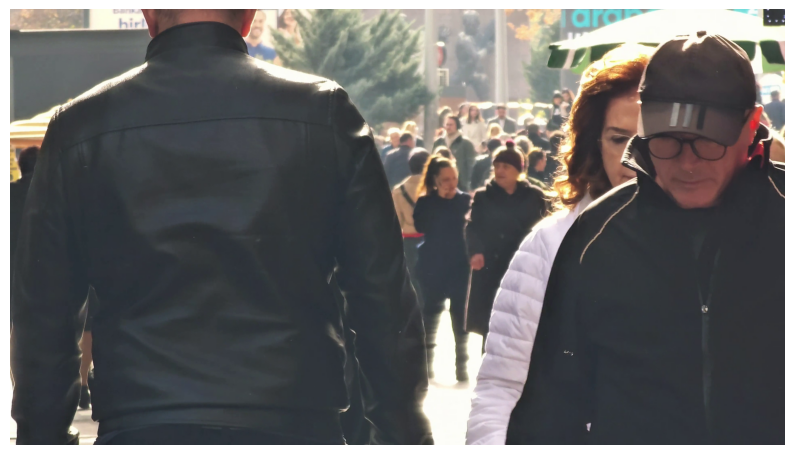

In [6]:
# Case Study 2: Access Control in Restricted Zones
dataset_path = "D:/23108106/Dataset/Faces"
images, labels, label_map = [], [], {}
current_label = 0
for person in os.listdir(dataset_path):
    person_folder = os.path.join(dataset_path, person)
    if os.path.isdir(person_folder):
        label_map[current_label] = person
        for img in os.listdir(person_folder):
            img_path = os.path.join(person_folder, img)
            img = cv2.imread(img_path)
            if img is None: continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(gray)
            labels.append(current_label)
        current_label += 1
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))
cap = cv2.VideoCapture("D:/23108106/Lecture A.mp4")
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
frame_skip = 5
frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    frame_count += 1
    if frame_count % frame_skip != 0: continue
    h, w = frame.shape[:2]
    scale = 640/w
    small_frame = cv2.resize(frame, (640, int(h*scale)))
    gray = cv2.cvtColor(small_frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.2, 4)
    for (x, y, w_f, h_f) in faces:
        roi_gray = gray[y:y+h_f, x:x+w_f]
        label, conf = recognizer.predict(roi_gray)
        status = "Access Granted" if conf < 80 else "Access Denied"
        color = (0,255,0) if conf < 80 else (0,0,255)
        name = label_map.get(label, "Unknown") if conf < 80 else "Unknown"
        x1, y1 = int(x/scale), int(y/scale)
        x2, y2 = int((x+w_f)/scale), int((y+h_f)/scale)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, f"{name} - {status}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    clear_output(wait=True)
    plt.show()

cap.release()

Access Denied (Confidence: 84)


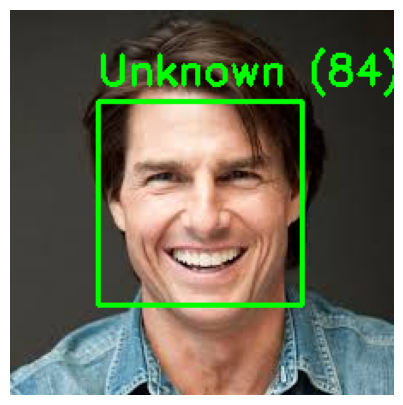

In [9]:
# Case Study 3: Face-Based Tagging in Photo Archives
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
def load_dataset(dataset_path):
    images = []
    labels = []
    label_dict = {}
    current_label = 0
    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)
        if os.path.isdir(person_path):
            label_dict[current_label] = person_name
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None and img.shape[0] > 0 and img.shape[1] > 0:
                    images.append(img)
                    labels.append(current_label)
                else:
                    print(f"Failed to load or invalid image: {img_path}")
            current_label += 1
    return images, labels, label_dict
dataset_path = "D:/23108106/Dataset/Faces"
images, labels, label_dict = load_dataset(dataset_path)
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))
recognizer.save('D:/23108106/face_recognizer.yml')
with open("label_map.txt", "w") as f:
    for label, name in label_dict.items():
        f.write(f"{label}:{name}\n")
recognizer.read('D:/23108106/face_recognizer.yml')
label_map = {}
with open("label_map.txt", "r") as f:
    for line in f:
        label, name = line.strip().split(":")
        label_map[int(label)] = name
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
test_img_path = "D:/23108106/A23.jpg"
img = cv2.imread(test_img_path)
if img is None:
    raise ValueError("Test image not loaded! Check the path.")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,    
    minNeighbors=3,       
    minSize=(30, 30)       
)
confidence_threshold = 80  
if len(faces) == 0:
    print("No faces detected!")
else:
    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        label, confidence = recognizer.predict(roi_gray)
        name = label_map.get(label, "Unknown")
        display_name = name if confidence < confidence_threshold else "Unknown"
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img, f"{display_name} ({int(confidence)})",
                    (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        if display_name != "Unknown":
            print(f"Unlocked: {display_name} (Confidence: {int(confidence)})")
        else:
            print(f"Access Denied (Confidence: {int(confidence)})")
plt.figure(figsize=(8,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

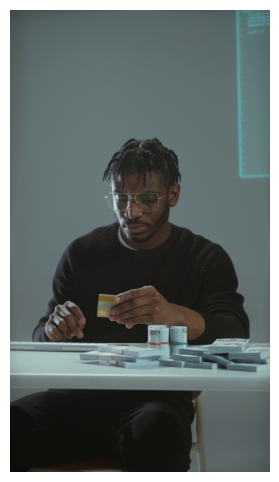

In [10]:
# Case Study 4: Real-Time Intruder Detection Using Face Detection
video_path = "D:/23108106/SSA.mp4"
cap = cv2.VideoCapture(video_path)
frame_skip = 5
frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    frame_count += 1
    if frame_count % frame_skip != 0: continue
    h, w = frame.shape[:2]
    scale = 640/w
    small_frame = cv2.resize(frame, (640, int(h*scale)))
    gray = cv2.cvtColor(small_frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.2, 4)
    for (x,y,w_f,h_f) in faces:
        roi_gray = gray[y:y+h_f, x:x+w_f]
        label, conf = recognizer.predict(roi_gray)
        if conf >= 80:
            x1, y1 = int(x/scale), int(y/scale)
            x2, y2 = int((x+w_f)/scale), int((y+h_f)/scale)
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,0,255), 2)
            cv2.putText(frame, "Intruder", (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
            print("Intruder detected!")
    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    clear_output(wait=True)
    plt.show()
cap.release()

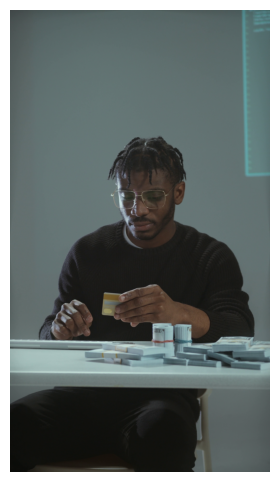

Detection log saved -> detected_criminals.csv


In [11]:
# Case Study 5: Criminal Identification Using Face Recognition in Law Enforcement
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import clear_output
dataset_path = "D:/23108106/Dataset/Faces"
images, labels, label_map = [], [], {}
current_label = 0
for criminal in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, criminal)
    if os.path.isdir(folder):
        label_map[current_label] = criminal
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            if img is None: continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(gray)
            labels.append(current_label)
        current_label += 1
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))
video_path = "D:/23108106/SSA.mp4"
cap = cv2.VideoCapture(video_path)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
frame_skip = 6
frame_count = 0
detected_criminals = {}
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1
    if frame_count % frame_skip != 0:
        continue
    h, w = frame.shape[:2]
    scale = 640 / w
    small_frame = cv2.resize(frame, (640, int(h * scale)))
    gray = cv2.cvtColor(small_frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.2, 4)
    for (x, y, w_f, h_f) in faces:
        roi_gray = gray[y:y + h_f, x:x + w_f]
        label, conf = recognizer.predict(roi_gray)
        if conf < 80:
            name = label_map[label]
            detected_criminals[name] = detected_criminals.get(name, 0) + 1
            color = (0, 0, 255)  # Red for criminal
            status_text = f"Criminal: {name} ({int(conf)})"
            print(f"Alert! Criminal Detected: {name} with confidence {int(conf)}")
        else:
            name = "Unknown"
            color = (0, 255, 0)
            status_text = "Unknown"
        x1, y1 = int(x / scale), int(y / scale)
        x2, y2 = int((x + w_f) / scale), int((y + h_f) / scale)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, status_text, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    clear_output(wait=True)
    plt.show()
cap.release()
import pandas as pd
df = pd.DataFrame(list(detected_criminals.items()), columns=["Name", "Times_Detected"])
df.to_csv("detected_criminals.csv", index=False)
print("Detection log saved -> detected_criminals.csv")